# Helper functions

In [4]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# -----------------------------
# Core helpers (unchanged logic)
# -----------------------------
def process_attribution_data(df_group):
    """Parses and aggregates attribution scores for a specific group into a (rows x layers) matrix."""
    pat = re.compile(r"^(Context|Entity|Query|Last_token|Final)_(\d+)\/(\d+)$")

    def parse_subbin(s):
        m = pat.match(str(s))
        if not m:
            return ("Other", 0, 1)
        return (m.group(1), int(m.group(2)), int(m.group(3)))

    df_group = df_group.copy()
    parsed = df_group["Subbin"].apply(parse_subbin)
    df_group["BinParsed"] = parsed.apply(lambda x: x[0])
    df_group["SubIdx"]    = parsed.apply(lambda x: x[1])
    df_group["NSub"]      = parsed.apply(lambda x: x[2])

    keep_bins = ["Context", "Entity", "Query", "Last_token", "Final"]
    df_group = df_group[df_group["BinParsed"].isin(keep_bins)].copy()

    agg = df_group.groupby(["BinParsed", "NSub", "SubIdx", "Layer"], as_index=False)["Attribution"].mean()
    bin_order = {"Context": 0, "Entity": 1, "Query": 2, "Last_token": 3, "Final": 4}
    agg["BinOrder"] = agg["BinParsed"].map(bin_order)

    rows_info = (
        agg[["BinParsed", "NSub", "SubIdx", "BinOrder"]]
        .drop_duplicates()
        .sort_values(["BinOrder", "SubIdx"])
    )
    row_index = rows_info.set_index(["BinParsed", "NSub", "SubIdx"]).index
    row_labels = [f"{b}_{i}/{n}" for (b, n, i) in row_index]

    mat = (
        agg.pivot_table(
            index=["BinParsed", "NSub", "SubIdx"],
            columns="Layer",
            values="Attribution",
            fill_value=0.0,
        )
        .reindex(row_index)
    )

    return mat, row_labels, rows_info


def get_top_two_analysis(
    mat,
    group_name,
    bin_level="BinParsed",
    layer_level="Layer",   # if layers are in a MultiIndex, else ignored
    entity_bin="Entity",
    last_bin="Final",      # you called this "Final"
):
    """Entity max over FIRST HALF layers vs Final max over LAST HALF layers."""
    def _split_layers(values):
        values_sorted = sorted(list(values))
        mid = len(values_sorted) // 2
        return values_sorted[:mid], values_sorted[mid:]

    def _nanmax_block(block):
        return np.nanmax(block.to_numpy())

    try:
        block_entity = mat.xs(entity_bin, level=bin_level, drop_level=False)
    except KeyError:
        return f"{group_name}: No '{entity_bin}' rows in mat."

    try:
        block_last = mat.xs(last_bin, level=bin_level, drop_level=False)
    except KeyError:
        return f"{group_name}: No '{last_bin}' rows in mat."

    # Case A: layers live in the INDEX (MultiIndex w/ "Layer" level)
    if hasattr(mat.index, "names") and layer_level in (mat.index.names or []):
        layers = mat.index.get_level_values(layer_level).unique()
        first_layers, last_layers = _split_layers(layers)

        entity_first = block_entity.loc[
            block_entity.index.get_level_values(layer_level).isin(first_layers)
        ]
        last_last = block_last.loc[
            block_last.index.get_level_values(layer_level).isin(last_layers)
        ]

        entity_max = _nanmax_block(entity_first)
        last_max   = _nanmax_block(last_last)

    # Case B: layers live in the COLUMNS (MultiIndex columns w/ "Layer" level)
    elif hasattr(mat.columns, "names") and layer_level in (mat.columns.names or []):
        layers = mat.columns.get_level_values(layer_level).unique()
        first_layers, last_layers = _split_layers(layers)

        entity_first = block_entity.loc[:, block_entity.columns.get_level_values(layer_level).isin(first_layers)]
        last_last    = block_last.loc[:,  block_last.columns.get_level_values(layer_level).isin(last_layers)]

        entity_max = _nanmax_block(entity_first)
        last_max   = _nanmax_block(last_last)

    # Case C: plain columns are layer numbers; split by position
    else:
        ncols = mat.shape[1]
        mid = ncols // 2
        entity_max = np.nanmax(block_entity.iloc[:, :mid].to_numpy())
        last_max   = np.nanmax(block_last.iloc[:, mid:].to_numpy())

    if last_max == 0 or np.isnan(last_max):
        return f"{group_name}: Final max (last-half) is 0/NaN, cannot compute ratio."

    return {
        "Group": group_name,
        "Entity_max_first_half_layers": float(entity_max),
        "Final_max_last_half_layers": float(last_max),
        "Difference": float(entity_max - last_max),
        "Ratio": float(entity_max / last_max),
    }




def get_entity_vs_nonentity_max(
    mat,
    group_name,
    *,
    bin_level="BinParsed",
    entity_bin="Entity",
):
    """Compare max attribution in Entity vs max attribution anywhere outside Entity (no layer splitting)."""

    def _nanmax_block(block):
        return np.nanmax(block.to_numpy())

    # must have bin_level in index
    if not (hasattr(mat.index, "names") and bin_level in (mat.index.names or [])):
        raise ValueError(
            f"{group_name}: mat.index must be a MultiIndex containing level '{bin_level}'"
        )

    # Entity rows
    try:
        block_entity = mat.xs(entity_bin, level=bin_level, drop_level=False)
    except KeyError:
        return f"{group_name}: No '{entity_bin}' rows in mat."

    # Non-Entity rows (everything else at bin_level)
    bins = mat.index.get_level_values(bin_level)
    block_non = mat.loc[bins != entity_bin]
    if block_non.shape[0] == 0:
        return f"{group_name}: No non-'{entity_bin}' rows in mat."

    entity_max = _nanmax_block(block_entity)
    non_max    = _nanmax_block(block_non)

    if non_max == 0 or np.isnan(non_max):
        return f"{group_name}: Non-entity max is 0/NaN, cannot compute ratio."

    return {
        "Group": group_name,
        "Entity_max": float(entity_max),
        "NonEntity_max": float(non_max),
        "Difference": float(entity_max - non_max),
        "Ratio": float(entity_max / non_max),
    }

def fmt(stats):
    if isinstance(stats, str):
        return stats
    return (
        f"{stats['Group']} -> "
        f"Diff (Entity-Final): {stats['Difference']:.4f}, "
        f"Ratio (Entity/Final): {stats['Ratio']:.4f} "
        f"(Entity_max_first_half: {stats['Entity_max_first_half_layers']:.4f}, "
        f"Final_max_last_half: {stats['Final_max_last_half_layers']:.4f})"
    )
def fmt_nonentity(stats):
    if isinstance(stats, str):
        return stats
    return (
        f"{stats['Group']} -> "
        f"Diff (Entity-NonEntity): {stats['Difference']:.4f}, "
        f"Ratio (Entity/NonEntity): {stats['Ratio']:.4f} "
        f"(Entity_max: {stats['Entity_max']:.4f}, "
        f"NonEntity_max: {stats['NonEntity_max']:.4f})"
    )

# -----------------------------------------
# ONE generalized function to run everything
# -----------------------------------------
def plot_binned_attribution_panels(
    base: str,
    pattern: str,
    *,
    category: str | None = None,
    groups: list[str],
    titles: list[str] | None = None,
    cmap: str = "Greens",
    figsize=(20, 8),
    sharey=True,
    global_scale=True,          # kept for backward compat
    use_powernorm: bool = False,
    gamma: float = 0.3,
    bins_for_separators=("Context", "Entity", "Query", "Last_token", "Final"),
    stats_entity_bin="Entity",
    stats_last_bin="Final",
    print_stats=True,
    manual_vmax=None,

    # NEW:
    separate_context_scale: bool = False,
    context_groups: list[str] | set[str] = ("VisTxtCont",),     # <- your contextual group(s)
    context_titles: list[str] | set[str] | None = None,         # optional: match by title instead
):
    full_pattern = os.path.join(base, pattern)
    files = sorted(glob.glob(full_pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"No files matched pattern: {full_pattern}")

    print(f"Found {len(files)} slice files")
    df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    if category is not None:
        df_all = df_all[df_all["Category"] == category].copy()
        print(f"Filtered Category='{category}' -> n={len(df_all)} rows")
    print(df_all['Group'].value_counts())
    # Titles default
    if titles is None:
        titles = groups
    if len(titles) != len(groups):
        raise ValueError("titles must be same length as groups (or None).")

    context_groups = set(context_groups)
    if context_titles is not None:
        context_titles = set(context_titles)

    # Build mats per group in requested order
    mats, labels_list, info_list = [], [], []
    for g in groups:
        df_g = df_all[df_all["Group"] == g]
        if df_g.empty:
            print(
                f"Group '{g}' has 0 rows after filtering. "
                f"Available groups: {sorted(df_all['Group'].unique())}"
            )
            # raise ValueError(
            #     f"Group '{g}' has 0 rows after filtering. "
            #     f"Available groups: {sorted(df_all['Group'].unique())}"
            # )
        mat, labels, info = process_attribution_data(df_g)
        mats.append(mat)
        labels_list.append(labels)
        info_list.append(info)

    # --------- NEW: scale logic ----------
    if separate_context_scale:
        # Decide which panels are "contextual"
        is_context = []
        for g, t in zip(groups, titles):
            if context_titles is not None:
                is_context.append(t in context_titles)
            else:
                is_context.append(g in context_groups)

        context_mats = [m for m, flag in zip(mats, is_context) if flag]
        other_mats   = [m for m, flag in zip(mats, is_context) if not flag]

        if len(context_mats) == 0:
            raise ValueError("separate_context_scale=True but no contextual panels matched. "
                             "Adjust context_groups/context_titles.")

        context_vmax = max(m.max().max() for m in context_mats)
        other_vmax   = max(m.max().max() for m in other_mats) if len(other_mats) else context_vmax

        # Each panel gets a vmax depending on which bucket it’s in
        vmax_per_panel = [context_vmax if flag else other_vmax for flag in is_context]

    else:
        # Old behavior
        if global_scale:
            gvmax = max(m.max().max() for m in mats)
            vmax_per_panel = [gvmax] * len(mats)
        else:
            vmax_per_panel = [None] * len(mats)
    # ------------------------------------

    # Plot
    fig, axes = plt.subplots(1, len(groups), figsize=figsize, sharey=sharey)
    if len(groups) == 1:
        axes = [axes]

    for i, (ax, mat, labels, info, title, group_name) in enumerate(
        zip(axes, mats, labels_list, info_list, titles, groups)
    ):
        A = mat.to_numpy()
        layers = mat.columns.to_numpy()

        vmax_here = vmax_per_panel[i]
        imshow_kwargs = dict(
            aspect="auto",
            origin="upper",
            interpolation="nearest",
            cmap=cmap,
        )

        if vmax_here is None:
            vmax_here = np.nanmax(A) if np.isfinite(np.nanmax(A)) else 1.0

        if use_powernorm:
            im = ax.imshow(A, norm=PowerNorm(gamma=gamma, vmin=0, vmax=vmax_here), **imshow_kwargs)
        else:
            if manual_vmax:
                vmax_here = manual_vmax
            im = ax.imshow(A, vmin=0, vmax=vmax_here, **imshow_kwargs)

        ax.set_title(f"MLP: Attribution: {title}", fontsize=16, pad=20)
        ax.set_xlabel("Transformer Layer", fontsize=12)

        xticks = np.linspace(0, len(layers) - 1, num=min(10, len(layers)), dtype=int)
        ax.set_xticks(xticks)
        ax.set_xticklabels(layers[xticks])

        if i == 0:
            ax.set_yticks(np.arange(len(labels)))
            ax.set_yticklabels(labels, fontsize=9)
            ax.set_ylabel("Subbin (Sequence Position)", fontsize=12)

        # separators between bins
        start_rows = []
        info_bins = info["BinParsed"].to_numpy()
        for b in bins_for_separators:
            idxs = np.where(info_bins == b)[0]
            if len(idxs):
                start_rows.append(int(idxs.min()))
        for r in start_rows[1:]:
            ax.axhline(r - 0.5, color="black", linewidth=0.8, alpha=0.4)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean Attribution Score")

    plt.tight_layout()
    plt.show()

    if print_stats:
        for mat, title, group_name in zip(mats, titles, groups):

            # --- Original (Entity vs Final split-halves)
            stats_split = get_top_two_analysis(
                mat,
                f"MLP: {title} [{group_name}]",
                entity_bin=stats_entity_bin,
                last_bin=stats_last_bin,
            )
            print(fmt(stats_split))

            # --- New (Entity vs NonEntity global max)
            stats_non = get_entity_vs_nonentity_max(
                mat,
                f"MLP: {title} [{group_name}]",
                entity_bin=stats_entity_bin,
            )
            print(fmt_nonentity(stats_non))

            print("-" * 80)

    return {
        "df_all": df_all,
        "files": files,
        "groups": groups,
        "titles": titles,
        "mats": mats,
        "labels": labels_list,
        "info": info_list,
        "vmax_per_panel": vmax_per_panel,
    }




In [5]:
# Text helpers
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
def entity_vs_final_ratio(mat, group_name, entity_bin="Entity", final_bin="Final"):
    # get max within a specific BinParsed block
    def bin_max(bin_name):
        try:
            block = mat.xs(bin_name, level="BinParsed", drop_level=False)
        except KeyError:
            return np.nan
        arr = block.to_numpy()
        return float(np.nanmax(arr)) if arr.size else np.nan

    ent = bin_max(entity_bin)
    fin = bin_max(final_bin)

    if not np.isfinite(ent) or not np.isfinite(fin):
        return {"Group": group_name, "error": f"Missing bin(s): Entity={entity_bin} or Final={final_bin}"}
    if fin == 0:
        return {"Group": group_name, "Entity_max": ent, "Final_max": fin, "Difference": ent - fin, "Ratio": np.inf}

    return {
        "Group": group_name,
        "Entity_max": ent,
        "Final_max": fin,
        "Difference": ent - fin,
        "Ratio": ent / fin,
    }


def plot_text_attr_two_panels(
    base: str,
    pattern: str,
    *,
    category: str = "Career_error",
    # each panel can be a list of groups to union together
    groups_context=("VisTxtCont", "VisParam_TextCont"),
    groups_parametric=("VisTxtParam", "VisCont_TextParam"),
    titles=("Text Answers Context", "Text Answers Parametric"),
    cmap="Greens",
    figsize=(20, 8),
    separate_scales: bool = False,     # NEW: if True, each chart gets its own vmax
    use_powernorm: bool = False,
    gamma: float = 0.6,
    print_stats: bool = True,
    show: bool = True,
):
    # ---------- load ----------
    full_pattern = os.path.join(base, pattern)
    files = sorted(glob.glob(full_pattern))
    print(f"Found {len(files)} slice files")
    if len(files) == 0:
        raise FileNotFoundError(f"No files matched: {full_pattern}")

    df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    if category is not None:
        df_all = df_all[df_all["Category"] == category].copy()
    print(df_all['Group'].value_counts())
    # ---------- process ----------
    pat = re.compile(r"^(Context|Entity|Query|Last_token|Final)_(\d+)\/(\d+)$")

    def process_attribution_data(df_group):
        def parse_subbin(s):
            m = pat.match(str(s))
            if not m:
                return ("Other", 0, 1)
            return (m.group(1), int(m.group(2)), int(m.group(3)))

        df_group = df_group.copy()
        parsed = df_group["Subbin"].apply(parse_subbin)
        df_group["BinParsed"] = parsed.apply(lambda x: x[0])
        df_group["SubIdx"]    = parsed.apply(lambda x: x[1])
        df_group["NSub"]      = parsed.apply(lambda x: x[2])

        keep_bins = ["Context", "Entity", "Query", "Last_token", "Final"]
        df_group = df_group[df_group["BinParsed"].isin(keep_bins)].copy()

        agg = df_group.groupby(["BinParsed", "NSub", "SubIdx", "Layer"], as_index=False)["Attribution"].mean()
        bin_order = {"Context": 0, "Entity": 1, "Query": 2, "Last_token": 3, "Final": 4}
        agg["BinOrder"] = agg["BinParsed"].map(bin_order)

        rows_info = (
            agg[["BinParsed", "NSub", "SubIdx", "BinOrder"]]
            .drop_duplicates()
            .sort_values(["BinOrder", "SubIdx"])
        )
        row_index = rows_info.set_index(["BinParsed", "NSub", "SubIdx"]).index
        row_labels = [f"{b}_{i}/{n}" for (b, n, i) in row_index]

        mat = (
            agg.pivot_table(
                index=["BinParsed", "NSub", "SubIdx"],
                columns="Layer",
                values="Attribution",
                fill_value=0.0,
            )
            .reindex(row_index)
        )
        return mat, row_labels, rows_info

    def subset_union(groups):
        groups = tuple(groups)
        df = df_all[df_all["Group"].isin(groups)].copy()
        if df.empty:
            raise ValueError(f"No rows for groups={groups}. Available groups: {sorted(df_all['Group'].unique())}")
        return df

    df_context = subset_union(groups_context)
    df_param   = subset_union(groups_parametric)
    print(df_context['Category'].value_counts())
    print(df_param['Category'].value_counts())

    mat_ctx, labels_ctx, info_ctx = process_attribution_data(df_context)
    mat_par, labels_par, info_par = process_attribution_data(df_param)

    mats   = [mat_ctx, mat_par]
    labels = [labels_ctx, labels_par]
    infos  = [info_ctx, info_par]

    # ---------- scaling ----------
    if separate_scales:
        vmaxs = [m.max().max() for m in mats]
    else:
        gvmax = max(m.max().max() for m in mats)
        vmaxs = [gvmax, gvmax]

    # ---------- plot ----------
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]

    for idx, (ax, mat, lab, info, title, vmax) in enumerate(zip(axes, mats, labels, infos, titles, vmaxs)):
        A = mat.to_numpy()
        layers = mat.columns.to_numpy()

        if use_powernorm:
            im = ax.imshow(
                A,
                aspect="auto",
                origin="upper",
                interpolation="nearest",
                cmap=cmap,
                norm=PowerNorm(gamma=gamma, vmin=0, vmax=vmax),
            )
        else:
            im = ax.imshow(
                A,
                aspect="auto",
                origin="upper",
                interpolation="nearest",
                cmap=cmap,
                vmin=0,
                vmax=vmax,
            )

        scale_tag = "own scale" if separate_scales else "shared scale"
        ax.set_title(f"MLP: Attribution: {title} ({scale_tag})", fontsize=16, pad=20)
        ax.set_xlabel("Transformer Layer", fontsize=12)

        xticks = np.linspace(0, len(layers) - 1, num=min(10, len(layers)), dtype=int)
        ax.set_xticks(xticks)
        ax.set_xticklabels(layers[xticks])

        if idx == 0:
            ax.set_yticks(np.arange(len(lab)))
            ax.set_yticklabels(lab, fontsize=9)
            ax.set_ylabel("Subbin (Sequence Position)", fontsize=12)

        # bin separators
        start_rows = []
        for b in ["Context", "Entity", "Query", "Last_token", "Final"]:
            idxs = np.where(info["BinParsed"].to_numpy() == b)[0]
            if len(idxs):
                start_rows.append(int(idxs.min()))
        for r in start_rows[1:]:
            ax.axhline(r - 0.5, color="black", linewidth=0.8, alpha=0.4)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean Attribution Score")

    plt.tight_layout()
    if show:
        plt.show()

    # ---------- stats ----------
    def get_top_two_analysis(mat, group_name):
        values = mat.to_numpy().flatten()
        unique_sorted = np.sort(np.unique(values))[::-1]
        if len(unique_sorted) < 2:
            return {"Group": group_name, "error": "Not enough unique values"}
        highest = unique_sorted[0]
        second = unique_sorted[1]
        return {
            "Group": group_name,
            "Highest": float(highest),
            "Second": float(second),
            "Difference": float(highest - second),
            "Ratio": float(highest / second) if second != 0 else np.inf,
        }

    stats_ctx = entity_vs_final_ratio(mat_ctx, f"MLP: {titles[0]}", entity_bin="Entity", final_bin="Final")
    stats_par = entity_vs_final_ratio(mat_par, f"MLP: {titles[1]}", entity_bin="Entity", final_bin="Final")

    if print_stats:
        def _p(s):
            if "error" in s:
                print(f"{s['Group']} -> {s['error']}")
            else:
                print(
                    f"{s['Group']} -> Entity_max: {s['Entity_max']:.4f}, "
                    f"Final_max: {s['Final_max']:.4f}, "
                    f"Diff: {s['Difference']:.4f}, "
                    f"Entity/Final Ratio: {s['Ratio']:.4f}"
                )
        _p(stats_ctx)
        _p(stats_par)

    return {
        "files": files,
        "df_all": df_all,
        "df_context": df_context,
        "df_parametric": df_param,
        "mat_context": mat_ctx,
        "mat_parametric": mat_par,
        "labels_context": labels_ctx,
        "labels_parametric": labels_par,
        "info_context": info_ctx,
        "info_parametric": info_par,
        "vmaxs": vmaxs,
        "stats_context": stats_ctx,
        "stats_parametric": stats_par,
    }




# Qwen

Found 10 slice files
Filtered Category='location_error' -> n=162400 rows
Group
VisTxtCont          112000
VisTxtParam          32200
VisCont_TxtParam      9800
VisParam_TxtCont      8400
Name: count, dtype: int64


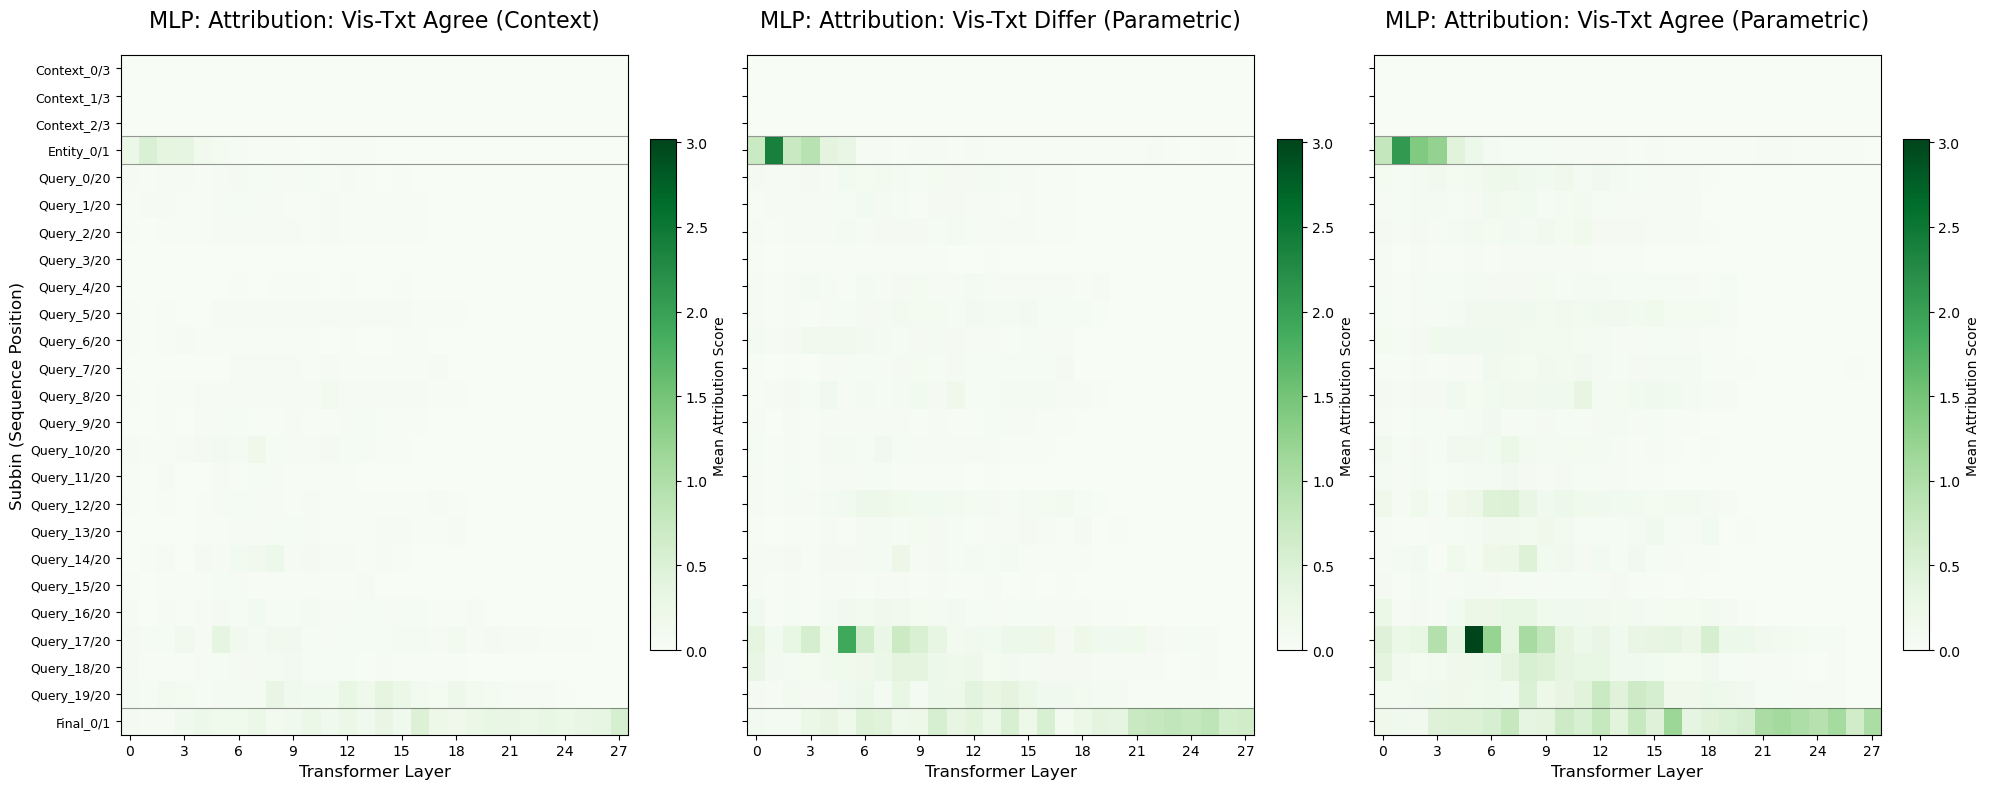

MLP: Vis-Txt Agree (Context) [VisTxtCont] -> Diff (Entity-Final): -0.0490, Ratio (Entity/Final): 0.9132 (Entity_max_first_half: 0.5159, Final_max_last_half: 0.5649)
MLP: Vis-Txt Agree (Context) [VisTxtCont] -> Diff (Entity-NonEntity): -0.0490, Ratio (Entity/NonEntity): 0.9132 (Entity_max: 0.5159, NonEntity_max: 0.5649)
--------------------------------------------------------------------------------
MLP: Vis-Txt Differ (Parametric) [VisParam_TxtCont] -> Diff (Entity-Final): 1.5493, Ratio (Entity/Final): 2.8404 (Entity_max_first_half: 2.3911, Final_max_last_half: 0.8418)
MLP: Vis-Txt Differ (Parametric) [VisParam_TxtCont] -> Diff (Entity-NonEntity): 0.4762, Ratio (Entity/NonEntity): 1.2487 (Entity_max: 2.3911, NonEntity_max: 1.9149)
--------------------------------------------------------------------------------
MLP: Vis-Txt Agree (Parametric) [VisTxtParam] -> Diff (Entity-Final): 0.9192, Ratio (Entity/Final): 1.7946 (Entity_max_first_half: 2.0759, Final_max_last_half: 1.1567)
MLP: Vis-T

In [20]:
#VISION
BASE = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Attr_Results"
OUT = plot_binned_attribution_panels(
    base=BASE,
    pattern="Attribution_Patching_Binned_qwen_slice*of10_mlp.csv",
    category="location_error",
    groups=["VisTxtCont", "VisParam_TxtCont", "VisTxtParam"],
    titles=["Vis-Txt Agree (Context)", "Vis-Txt Differ (Parametric)", "Vis-Txt Agree (Parametric)"],
    cmap="Greens",
    global_scale=True,
    use_powernorm=False,   
    gamma=0.6,
    separate_context_scale = False,
    #manual_vmax = 1.75
)

Found 10 slice files
Group
VisParam_TxtCont    78400
VisTxtParam         60900
VisTxtCont          50400
VisCont_TxtParam     2100
Name: count, dtype: int64
Category
Career_error    50400
Name: count, dtype: int64
Category
Career_error    60900
Name: count, dtype: int64


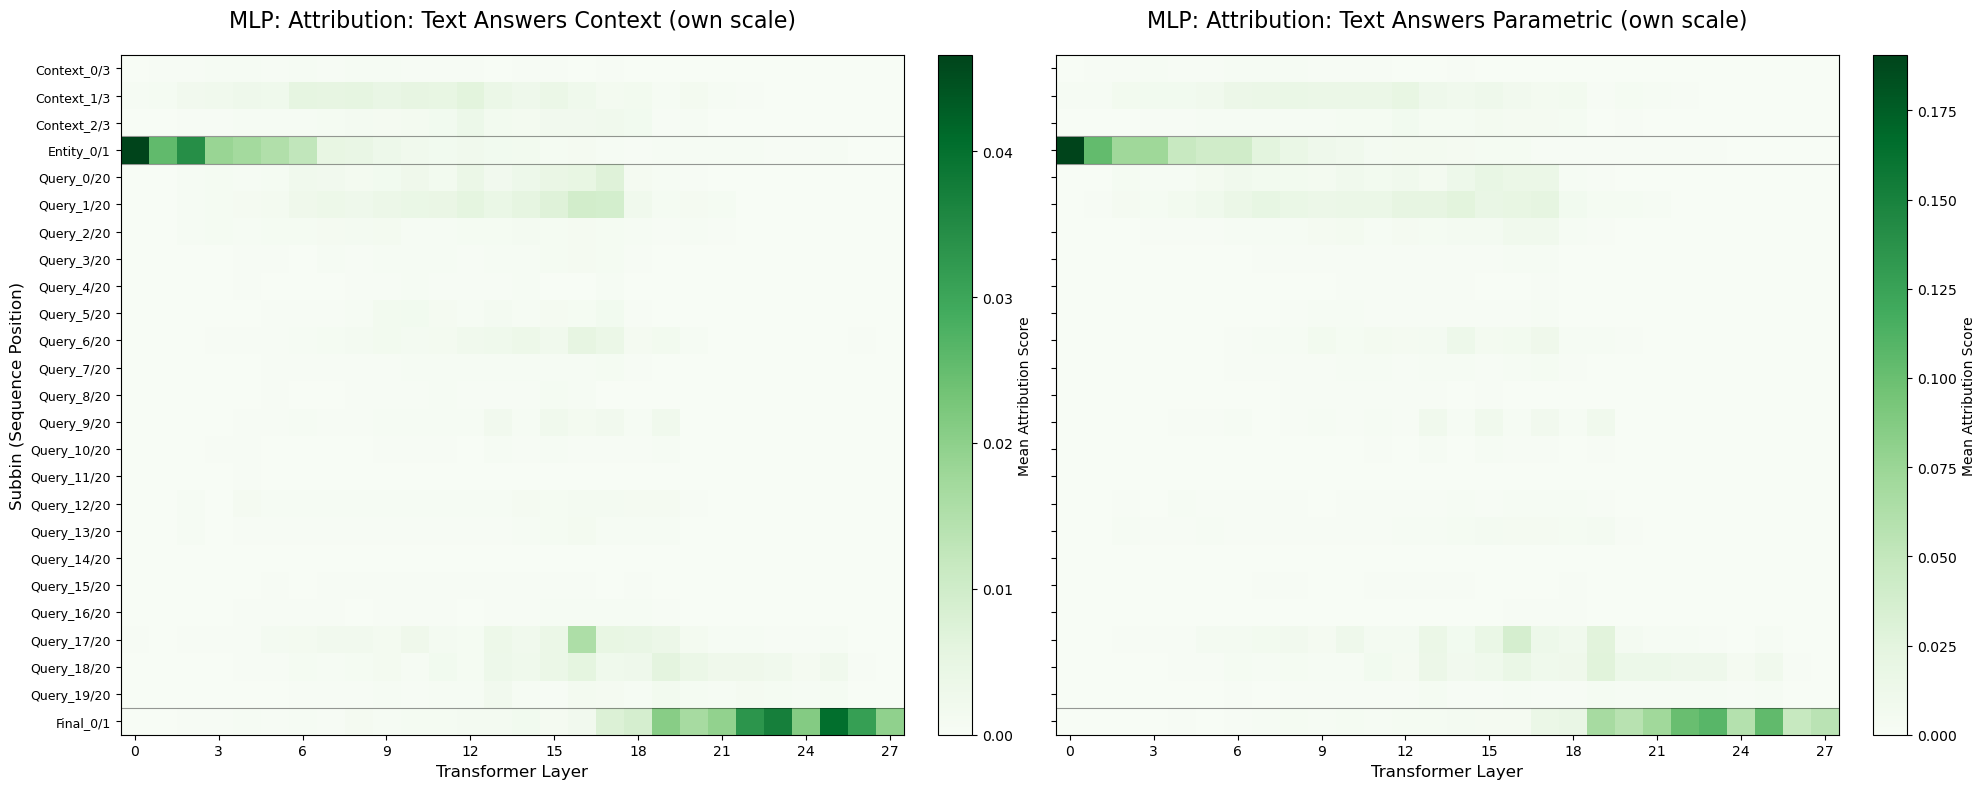

MLP: Text Answers Context -> Entity_max: 0.0466, Final_max: 0.0404, Diff: 0.0062, Entity/Final Ratio: 1.1540
MLP: Text Answers Parametric -> Entity_max: 0.1906, Final_max: 0.1086, Diff: 0.0821, Entity/Final Ratio: 1.7559


In [7]:
#Text
BASE = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Attr_Results"
OUT_TXT = plot_text_attr_two_panels(
    base=BASE,
    pattern="Attribution_Patching_Binned_qwen_text_slice*of10_mlp.csv",
    category="Career_error",
    groups_context=("VisTxtCont", "VisParam_TextCont"),
    groups_parametric=("VisTxtParam", "VisCont_TextParam"),
    separate_scales=True,   # <-- each chart on its own scale
    use_powernorm=False,
)

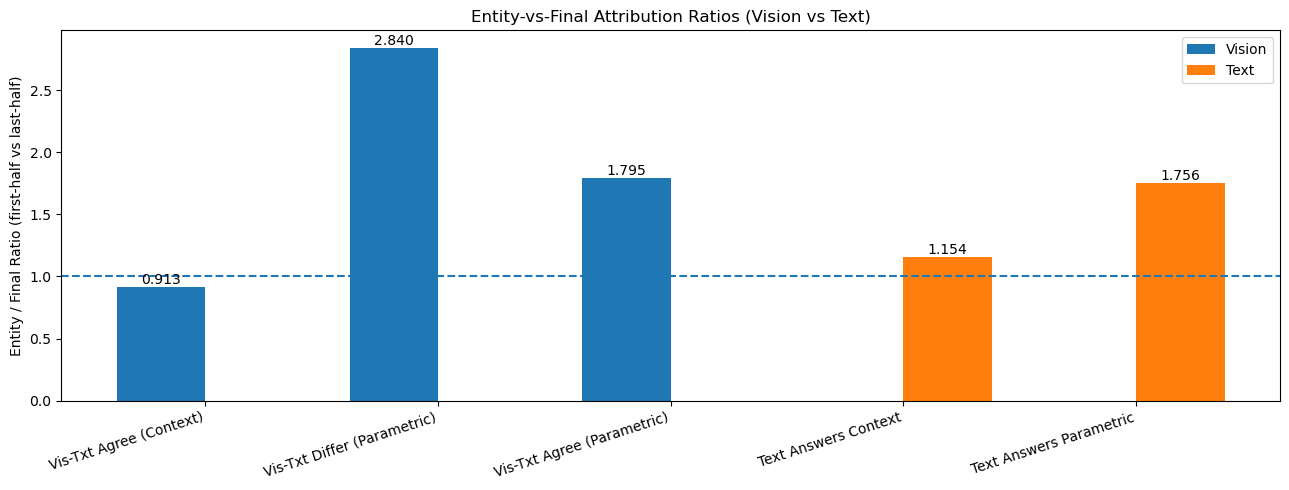

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- helper: compute SAME ratio definition for any mat ---
def entity_final_ratio(mat, entity_bin="Entity", final_bin="Final"):
    stats = get_top_two_analysis(
        mat,
        group_name="tmp",
        entity_bin=entity_bin,
        last_bin=final_bin,
    )
    if isinstance(stats, str):
        raise ValueError(stats)
    return stats["Ratio"]

# -------------------------
# VISION ratios (3 panels)
# -------------------------
vision_labels = OUT["titles"]
vision_ratios = [entity_final_ratio(m) for m in OUT["mats"]]

# -------------------------
# TEXT ratios (2 panels)
# -------------------------
text_labels = ["Text Answers Context", "Text Answers Parametric"]
text_mats   = [OUT_TXT["mat_context"], OUT_TXT["mat_parametric"]]
text_ratios = [entity_final_ratio(m) for m in text_mats]

# -------------------------
# Build union label set and align
# -------------------------
all_labels = list(vision_labels) + [l for l in text_labels if l not in vision_labels]

vision_map = dict(zip(vision_labels, vision_ratios))
text_map   = dict(zip(text_labels, text_ratios))

vision_y = np.array([vision_map.get(l, np.nan) for l in all_labels], dtype=float)
text_y   = np.array([text_map.get(l, np.nan) for l in all_labels], dtype=float)

x = np.arange(len(all_labels))
w = 0.38

plt.figure(figsize=(13, 5))

# Plot, skipping NaNs by masking
mask_v = np.isfinite(vision_y)
mask_t = np.isfinite(text_y)

bars_v = plt.bar(x[mask_v] - w/2, vision_y[mask_v], width=w, label="Vision")
bars_t = plt.bar(x[mask_t] + w/2, text_y[mask_t],   width=w, label="Text")

plt.axhline(1.0, linestyle="--")  # Entity == Final
plt.ylabel("Entity / Final Ratio (first-half vs last-half)")
plt.title("Entity-vs-Final Attribution Ratios (Vision vs Text)")
plt.xticks(x, all_labels, rotation=18, ha="right")
plt.legend()

# annotate values
def annotate(bars):
    for b in bars:
        h = b.get_height()
        plt.text(
            b.get_x() + b.get_width()/2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

annotate(bars_v)
annotate(bars_t)

plt.tight_layout()
plt.show()

# Gemma

Found 10 slice files
Filtered Category='Career_error' -> n=321600 rows
Group
VisTxtCont          237600
VisParam_TxtCont     48000
VisTxtParam          33600
VisCont_TxtParam      2400
Name: count, dtype: int64


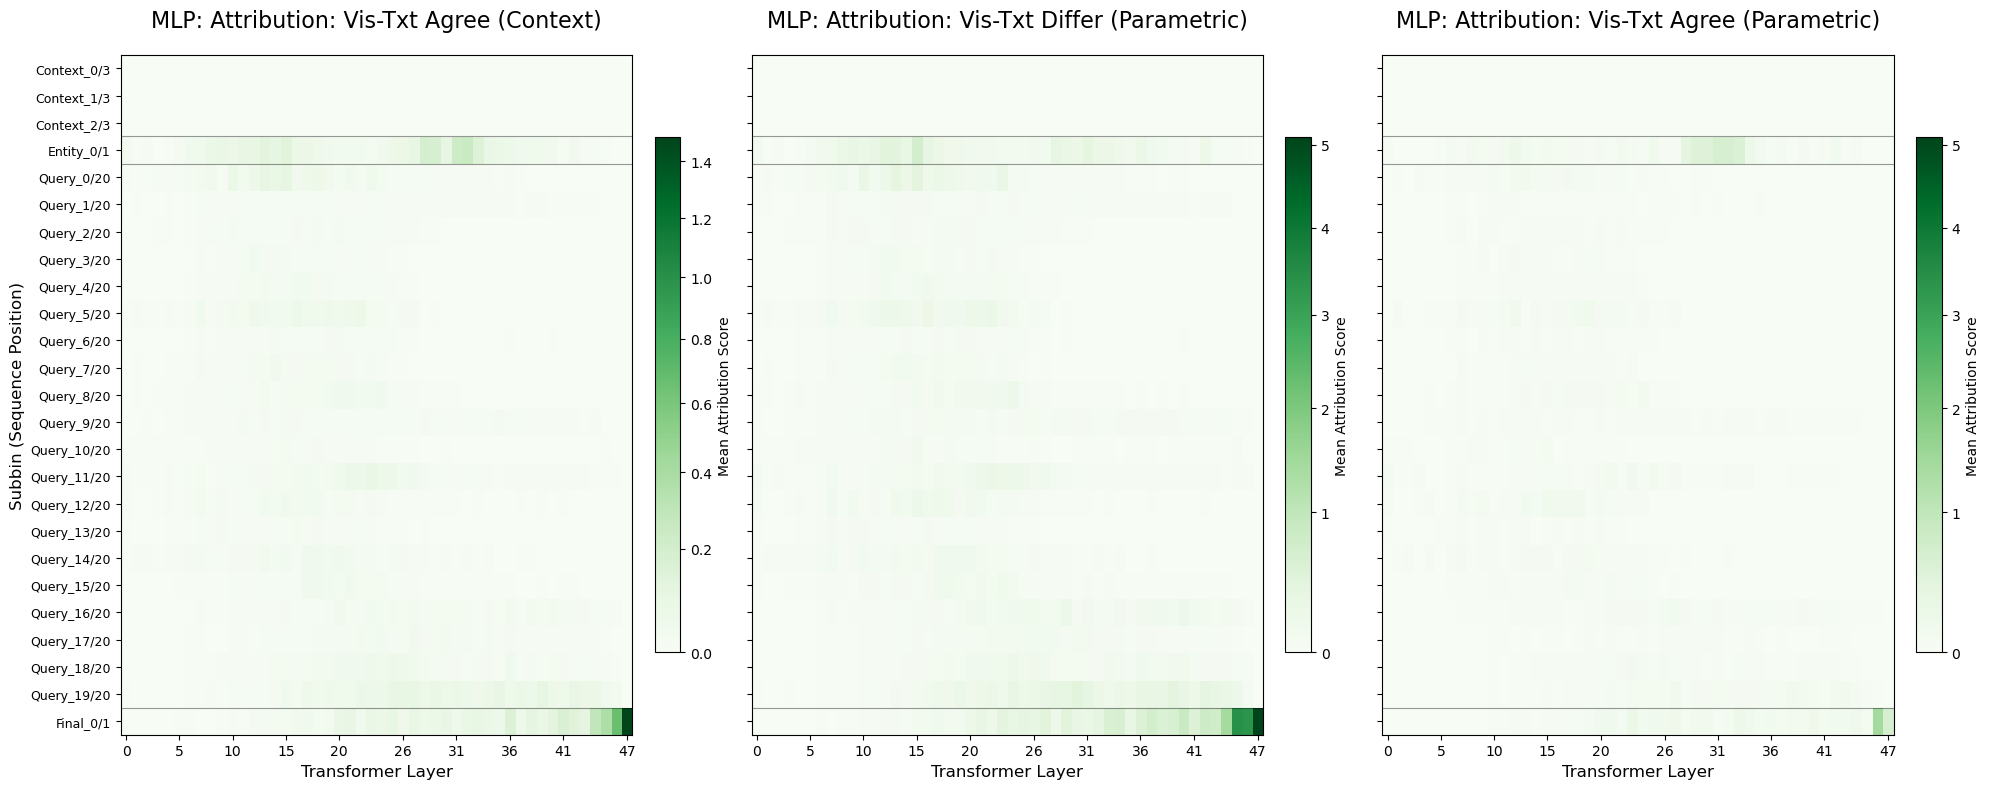

MLP: Vis-Txt Agree (Context) [VisTxtCont] -> Diff (Entity-Final): -1.3624, Ratio (Entity/Final): 0.0835 (Entity_max_first_half: 0.1241, Final_max_last_half: 1.4865)
MLP: Vis-Txt Agree (Context) [VisTxtCont] -> Diff (Entity-NonEntity): -1.2425, Ratio (Entity/NonEntity): 0.1641 (Entity_max: 0.2439, NonEntity_max: 1.4865)
--------------------------------------------------------------------------------
MLP: Vis-Txt Differ (Parametric) [VisParam_TxtCont] -> Diff (Entity-Final): -4.4183, Ratio (Entity/Final): 0.1321 (Entity_max_first_half: 0.6726, Final_max_last_half: 5.0909)
MLP: Vis-Txt Differ (Parametric) [VisParam_TxtCont] -> Diff (Entity-NonEntity): -4.4183, Ratio (Entity/NonEntity): 0.1321 (Entity_max: 0.6726, NonEntity_max: 5.0909)
--------------------------------------------------------------------------------
MLP: Vis-Txt Agree (Parametric) [VisTxtParam] -> Diff (Entity-Final): -1.2790, Ratio (Entity/Final): 0.1122 (Entity_max_first_half: 0.1616, Final_max_last_half: 1.4406)
MLP: Vi

In [9]:
#VISION
BASE = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Attr_Results"
OUT = plot_binned_attribution_panels(
    base=BASE,
    pattern="Attribution_Patching_Binned_gemma_slice*of10_mlp.csv",
    category="Career_error",
    groups=["VisTxtCont", "VisParam_TxtCont", "VisTxtParam"],
    titles=["Vis-Txt Agree (Context)", "Vis-Txt Differ (Parametric)", "Vis-Txt Agree (Parametric)"],
    cmap="Greens",
    global_scale=True,
    use_powernorm=True,   
    gamma=0.8,
    separate_context_scale = True,
)

Found 10 slice files
Group
VisTxtCont          237600
VisParam_TxtCont     48000
VisTxtParam          33600
VisCont_TxtParam      2400
Name: count, dtype: int64
Category
Career_error    237600
Name: count, dtype: int64
Category
Career_error    33600
Name: count, dtype: int64


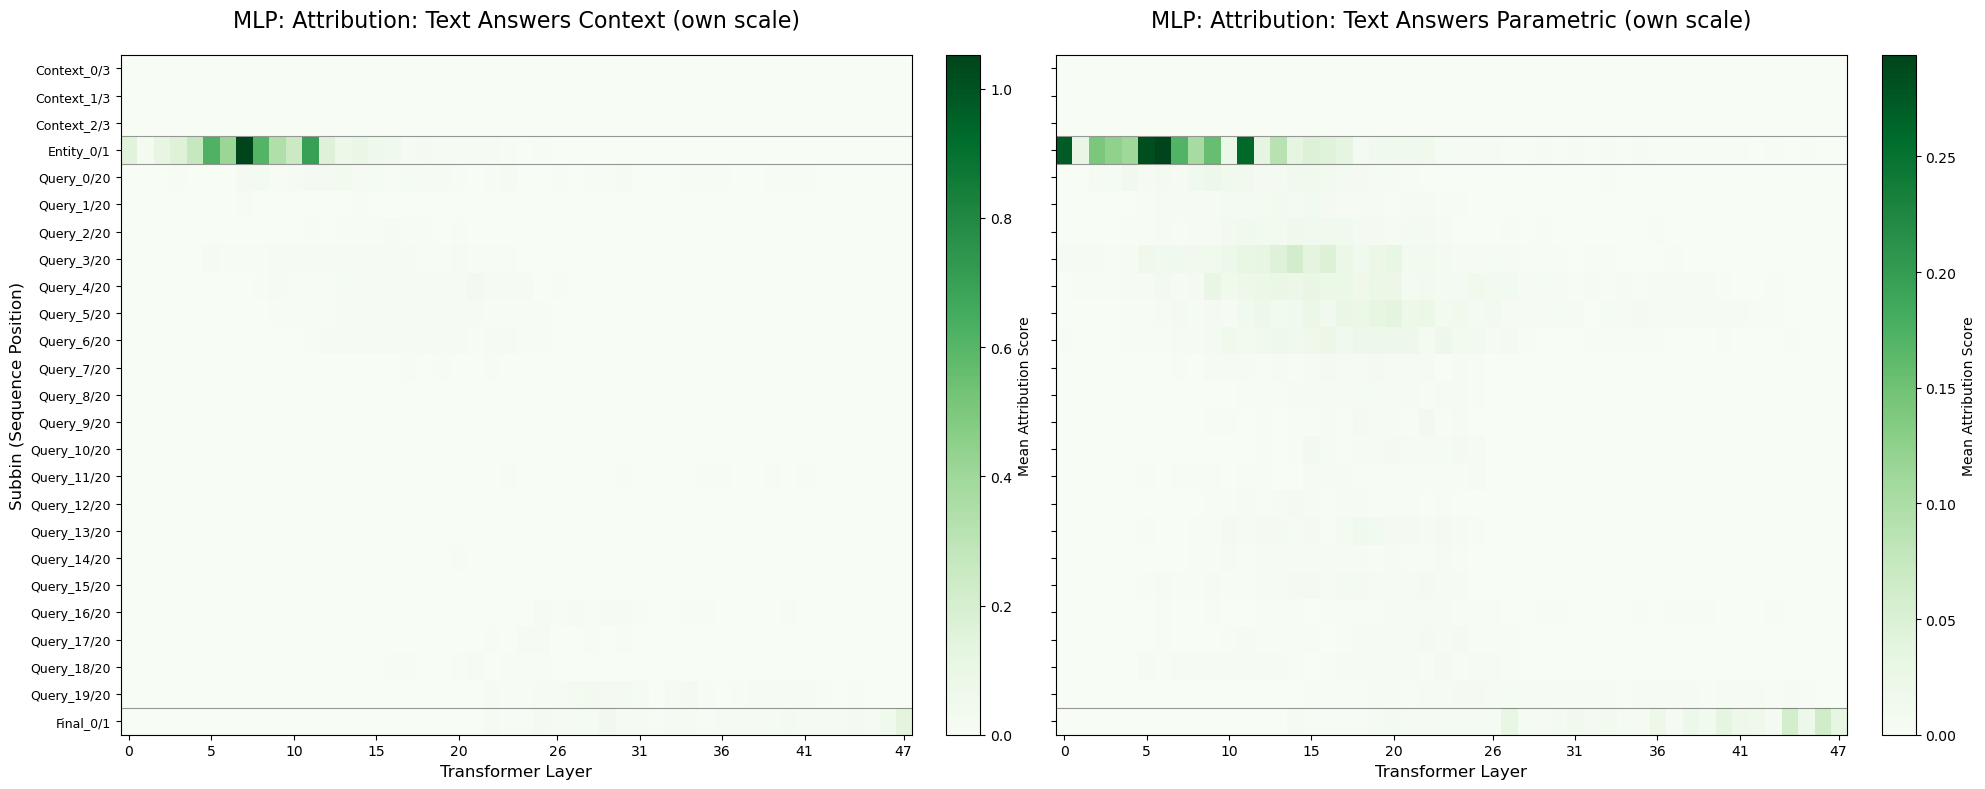

MLP: Text Answers Context -> Entity_max: 1.0526, Final_max: 0.1331, Diff: 0.9196, Entity/Final Ratio: 7.9113
MLP: Text Answers Parametric -> Entity_max: 0.2939, Final_max: 0.0624, Diff: 0.2315, Entity/Final Ratio: 4.7078


In [10]:
#Text
BASE = "/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Attr_Results"
OUT_TXT = plot_text_attr_two_panels(
    base=BASE,
    pattern="Attribution_Patching_Binned_gemma_text_slice*of10_mlp.csv",
    category="Career_error",
    groups_context=("VisTxtCont", "VisParam_TextCont"),
    groups_parametric=("VisTxtParam", "VisCont_TextParam"),
    separate_scales=True,   # <-- each chart on its own scale
    use_powernorm=False,
)

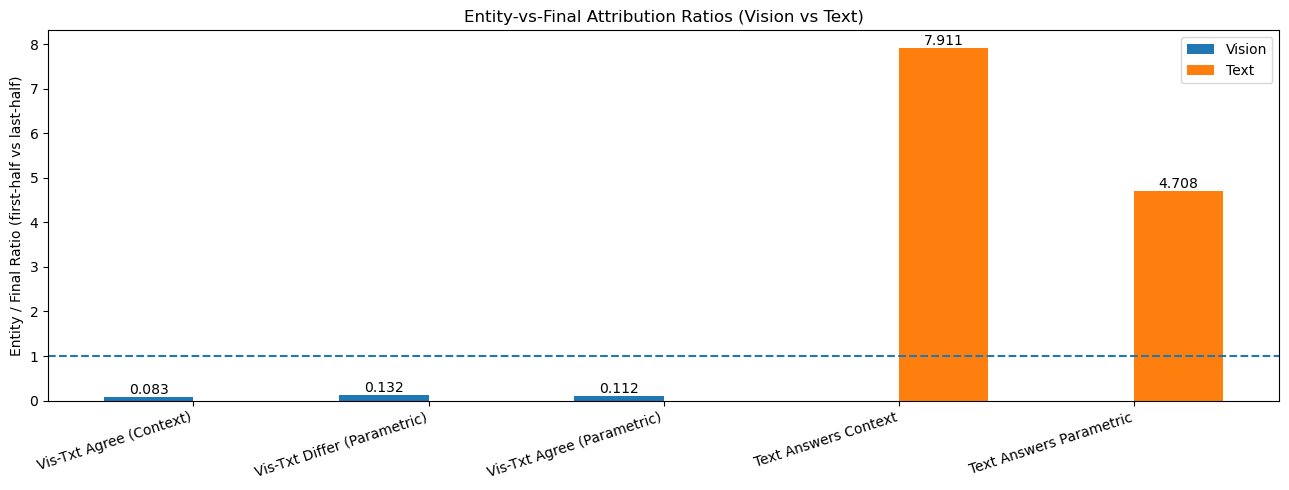

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- helper: compute SAME ratio definition for any mat ---
def entity_final_ratio(mat, entity_bin="Entity", final_bin="Final"):
    stats = get_top_two_analysis(
        mat,
        group_name="tmp",
        entity_bin=entity_bin,
        last_bin=final_bin,
    )
    if isinstance(stats, str):
        raise ValueError(stats)
    return stats["Ratio"]

# -------------------------
# VISION ratios (3 panels)
# -------------------------
vision_labels = OUT["titles"]
vision_ratios = [entity_final_ratio(m) for m in OUT["mats"]]

# -------------------------
# TEXT ratios (2 panels)
# -------------------------
text_labels = ["Text Answers Context", "Text Answers Parametric"]
text_mats   = [OUT_TXT["mat_context"], OUT_TXT["mat_parametric"]]
text_ratios = [entity_final_ratio(m) for m in text_mats]

# -------------------------
# Build union label set and align
# -------------------------
all_labels = list(vision_labels) + [l for l in text_labels if l not in vision_labels]

vision_map = dict(zip(vision_labels, vision_ratios))
text_map   = dict(zip(text_labels, text_ratios))

vision_y = np.array([vision_map.get(l, np.nan) for l in all_labels], dtype=float)
text_y   = np.array([text_map.get(l, np.nan) for l in all_labels], dtype=float)

x = np.arange(len(all_labels))
w = 0.38

plt.figure(figsize=(13, 5))

# Plot, skipping NaNs by masking
mask_v = np.isfinite(vision_y)
mask_t = np.isfinite(text_y)

bars_v = plt.bar(x[mask_v] - w/2, vision_y[mask_v], width=w, label="Vision")
bars_t = plt.bar(x[mask_t] + w/2, text_y[mask_t],   width=w, label="Text")

plt.axhline(1.0, linestyle="--")  # Entity == Final
plt.ylabel("Entity / Final Ratio (first-half vs last-half)")
plt.title("Entity-vs-Final Attribution Ratios (Vision vs Text)")
plt.xticks(x, all_labels, rotation=18, ha="right")
plt.legend()

# annotate values
def annotate(bars):
    for b in bars:
        h = b.get_height()
        plt.text(
            b.get_x() + b.get_width()/2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

annotate(bars_v)
annotate(bars_t)

plt.tight_layout()
plt.show()